In [1]:
import pandas as pd

file_path = r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_merged_data.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)


Couldn't import dot_parser, loading of dot files will not be possible.
Average similarity: 0.3051
Mean similarity: 0.305
Standard deviation: 0.177


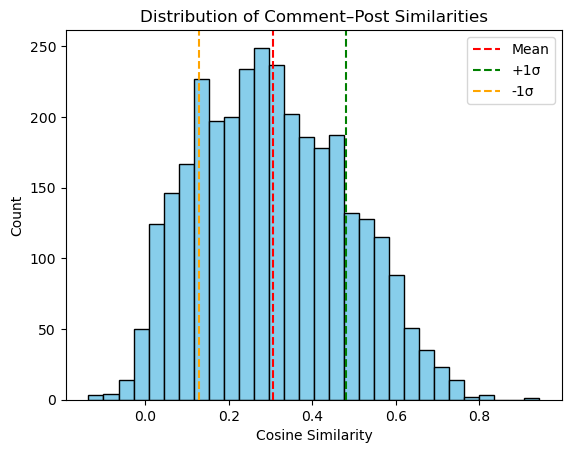

Similarity_Category
Average    2050
Low         581
High        566
Name: count, dtype: int64

In [2]:
# similarity of comments to its respective post


from sentence_transformers import SentenceTransformer, util
import numpy as np

# Encode posts from Affordability
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Encode posts and comments
post_embeddings = model.encode(df["text_ha"].tolist(), normalize_embeddings=False)
comment_embeddings = model.encode(df["text"].tolist(), normalize_embeddings=False)

# Compute cosine similarity per row (post-comment pair)
similarities = [
    util.cos_sim(post_embeddings[i], comment_embeddings[i]).item()
    for i in range(len(df))
]

df["Similarity"] = similarities
print(f"Average similarity: {np.mean(similarities):.4f}")

mean_sim = df["Similarity"].mean()
std_sim = df["Similarity"].std()

print(f"Mean similarity: {mean_sim:.3f}")
print(f"Standard deviation: {std_sim:.3f}")

import matplotlib.pyplot as plt

plt.hist(df["Similarity"], bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_sim, color='red', linestyle='--', label='Mean')
plt.axvline(mean_sim + 1* std_sim, color='green', linestyle='--', label='+1σ')
plt.axvline(mean_sim - 1* std_sim, color='orange', linestyle='--', label='-1σ')
plt.legend()
plt.title('Distribution of Comment–Post Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()


def categorize_similarity(x, mean, std):
    if x > mean + 1* std:
        return "High"
    elif x < mean - 1* std:
        return "Low"
    else:
        return "Average"

df["Similarity_Category"] = df["Similarity"].apply(lambda x: categorize_similarity(x, mean_sim, std_sim))
df["Similarity_Category"].value_counts()


In [3]:
df

,Unnamed: 0,parent_id,id,author_id,time,title,text,post_url,reactions,year,...,Sentiment,Intent,post_length,length_category,unique_words,unique_words_ratio,has_questions,has_urls,Similarity,Similarity_Category
0,0,ZmVlZGJhY2s6MjA0MDM2MDg0NjAxMzE1NA==,ZmVlZGJhY2s6MjA0MDM2MDg0NjAxMzE1NF8yMDQxMDI4Nj...,100001659249038,2019-04-02T22:14:59,NaN,hoeveel KWh hebben de zonnepanelen op de wezen...,0,0,2019,...,-1,Inquiry,65,short (50-150),49,75.38,0,0,0.747707,High
1,1,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzMw==,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzM18yMDc5MTcxNj...,1204819098,2018-12-21T15:37:26,NaN,Dan kom ik langs voor sleutels en krijg er gra...,0,0,2018,...,0,Criticism,61,short (50-150),47,77.05,0,0,0.276356,Average
2,2,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzMw==,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzM18yMDc4ODYzNj...,627271250,2018-12-21T10:57:48,NaN,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",0,0,2018,...,-1,Statement,61,short (50-150),47,77.05,0,0,0.226165,Average
3,3,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNA==,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNF8yMDc1OTI1Mj...,100001478616616,2018-08-01T15:22:31,NaN,Het zou beter zijn als Samenwerking een aantal...,0,0,2018,...,-1,Statement,51,short (50-150),48,94.12,1,1,0.304114,Average
4,4,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNA==,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNF8yMDczOTE5Nj...,100000855817347,2018-07-31T11:51:36,NaN,Leuk als je in een woning woont met warmtepomp...,0,0,2018,...,0,Criticism,51,short (50-150),48,94.12,1,1,0.555418,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,3192,ZmVlZGJhY2s6OTU1MjE0NDg0ODMyNDYw,ZmVlZGJhY2s6OTU1MjE0NDg0ODMyNDYwXzk1NTIyMDUzND...,100001182464975,2019-07-30T10:57:55,NaN,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,0,2,2019,...,0,Statement,46,tweet (<50),37,80.43,0,0,0.318798,Average
3193,3193,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIx,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIxXzk2NjA4NTQ4Nz...,596212634,2020-10-22T12:40:07,NaN,Is er genoeg ventilatie en / of kunnen ramen g...,0,0,2020,...,0,Inquiry,62,short (50-150),53,85.48,0,0,0.351911,Average
3194,3194,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIx,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIxXzk2NTQwMTMyNz...,100001224379149,2020-10-21T15:54:40,NaN,<PERSON> kan je dus straks gebruik van maken. ...,0,0,2020,...,0,Forward,62,short (50-150),53,85.48,0,0,0.205661,Average
3195,3195,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIx,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIxXzk2MzU0MDgwNz...,100002916564091,2020-10-19T10:14:18,NaN,Komen er nog meer werkplekken bij? Of blijft h...,0,0,2020,...,-1,Inquiry,62,short (50-150),53,85.48,0,0,0.615284,High


In [4]:
df.to_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_merged_data.csv", index=False)

In [133]:
import pandas as pd
CARLIJN_TEST_SET = pd.read_excel(R"C:\Users\20245179\OneDrive - TU Eindhoven\LLM_EngD_project\Intent recognition Comments\annotate_data_subset\TEST SET\TEST_data_Carlijn.xlsx")
data = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_merged_data.csv")

# For each comment in the test set, find only the FIRST matching index in data
indices_to_remove = []
for comment in CARLIJN_TEST_SET["Comments"]:
    match = data[(data["text"] == comment) & (~data.index.isin(indices_to_remove))].index
    if len(match) > 0:
        indices_to_remove.append(match[0])  # take only the first match

test_data_1 = data.loc[indices_to_remove].reset_index(drop=True)
training_data_1 = data.drop(index=indices_to_remove).reset_index(drop=True)

In [134]:
test_data_1

,Unnamed: 0,parent_id,id,author_id,time,title,text,post_url,reactions,year,...,Sentiment,Intent,post_length,length_category,unique_words,unique_words_ratio,has_questions,has_urls,Similarity,Similarity_Category
0,3170,ZmVlZGJhY2s6OTI3Mzk0NDQxNTcwNjE1,ZmVlZGJhY2s6OTI3Mzk0NDQxNTcwNjE1XzMzNDY3MDE0OT...,735885803,2023-04-06T20:48:45,NaN,Dank jullie wel,0,0,2023,...,1,Appreciation,100,short (50-150),82,82.00,0,0,0.398547,Average
1,45,ZmVlZGJhY2s6MjA4OTI1MDE2NDQ1ODMwOA==,ZmVlZGJhY2s6MjA4OTI1MDE2NDQ1ODMwOF8yMDg5MzI4MT...,100000586384994,2019-03-13T16:44:25,NaN,<PERSON>,0,0,2019,...,0,Forward,33,tweet (<50),31,93.94,0,1,0.112976,Low
2,2249,ZmVlZGJhY2s6NjI1MzgyODYyMTMyNTAyMQ==,ZmVlZGJhY2s6NjI1MzgyODYyMTMyNTAyMV82MjU0MTcwNj...,100003221340751,2021-10-07T15:11:56,NaN,Hartstikke mooi gebaar,0,1,2021,...,1,Statement,104,short (50-150),75,72.12,1,0,0.327650,Average
3,1013,ZmVlZGJhY2s6MTk4ODIwNTQ1NDU2MDk5OA==,ZmVlZGJhY2s6MTk4ODIwNTQ1NDU2MDk5OF8xOTg5NTc3Mz...,100006337412046,2019-02-16T07:40:54,NaN,Meten met twee maten doet de woningstichting o...,0,0,2019,...,-1,Criticism,33,tweet (<50),30,90.91,0,0,0.530310,High
4,1411,ZmVlZGJhY2s6MzE5NDk3MTk2ODU5NjQx,ZmVlZGJhY2s6MzE5NDk3MTk2ODU5NjQxXzMyNDIwMTE3Nj...,1237241591,2022-02-17T12:43:18,NaN,Zijn allemaal mooie acties! Maar enkel glas is...,0,0,2022,...,1,Criticism,74,short (50-150),60,81.08,1,1,0.346617,Average
5,2440,ZmVlZGJhY2s6NTAxODE1NTk1MzQ5MDMw,ZmVlZGJhY2s6NTAxODE1NTk1MzQ5MDMwXzg1ODkzNDQ0OD...,100021796992864,2022-12-20T16:56:10,NaN,Wauw mooi geworden,0,0,2022,...,1,Statement,134,short (50-150),95,70.90,0,0,0.255815,Average
6,520,ZmVlZGJhY2s6MjQ0NjkxNDQ5ODY5MTk0Nw==,ZmVlZGJhY2s6MjQ0NjkxNDQ5ODY5MTk0N18yNDQ4NDIwOT...,100004343983743,2019-06-05T12:09:47,NaN,Ja een betere isolatie stap 2,0,0,2019,...,0,Statement,127,short (50-150),99,77.95,0,0,0.261259,Average
7,2040,ZmVlZGJhY2s6NDY5MjU1MjkxODg5Njg5,ZmVlZGJhY2s6NDY5MjU1MjkxODg5Njg5XzY3MDU3OTUwMT...,100000093734190,2022-10-05T14:02:40,NaN,Wanneer krijgen wij HRxxx glas en Ducuton??,0,0,2022,...,0,Inquiry,66,short (50-150),48,72.73,1,1,0.116574,Low
8,2616,ZmVlZGJhY2s6NTEyMjgzNzg0MjYwMDY5,ZmVlZGJhY2s6NTEyMjgzNzg0MjYwMDY5XzE1MzU5NDM4Nj...,100005107840945,2022-12-02T14:17:23,NaN,Misschien beter isoleren scheeld ook aardig in...,0,1,2022,...,0,Statement,35,tweet (<50),30,85.71,1,0,0.140017,Average
9,2676,ZmVlZGJhY2s6NTI0NzM3ODYzMTEwNzI3,ZmVlZGJhY2s6NTI0NzM3ODYzMTEwNzI3XzIwNzAzMDI1MT...,100000439118957,2023-03-08T16:49:27,NaN,Ja ja en wij maar in tocht huizen wonen voor d...,0,0,2023,...,0,Criticism,53,short (50-150),43,81.13,0,1,0.372505,Average


In [135]:
wb_test = pd.read_excel(r"C:\Users\20245179\OneDrive - TU Eindhoven\LLM_EngD_project\Intent recognition Comments\annotate_data_subset\Roy_data\WB_200_Roy_to_label.xlsx")
all_wb_data = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\LLM_EngD_project\Data\WB\WB\all_wb_data.csv")
indices_to_remove = []
for comment in wb_test["Comments"]:
    match = all_wb_data[(all_wb_data["Comment"] == comment) & (~all_wb_data.index.isin(indices_to_remove))].index
    if len(match) > 0:
        indices_to_remove.append(match[0])

test_data_2 = all_wb_data.loc[indices_to_remove].reset_index(drop=True)
training_data_2 = all_wb_data.drop(index=indices_to_remove).reset_index(drop=True)
# Add PI and PI_Sentiment from wb_test
# Match on comment text to align rows correctly
#wb_test_normalized = wb_test[["Comments", "PI", "PI_Sentiment"]].drop_duplicates(subset="Comments")
test_data_2 = test_data_2.merge(wb_test, left_on="Comment", right_on="Comments", how="left").drop(columns="Comments")

print(test_data_2[["Comment", "PI", "PI_Sentiment"]].head())

print(f"Nulls in PI: {test_data_2['PI'].isna().sum()}")

                                             Comment         PI PI_Sentiment
0  Je huur moet wel boven de 575 zijn ze verlagen...  Statement      Neutral
1                   Nemen jullie de telefoon nog op?    Inquiry      Neutral
2  Hopelijk zo'n project weer in Stratum, dan kun...    Inquiry     Positive
3  Echt slecht je loopt alleen maar tegen problem...  Criticism     Negative
4  Zo zijn ze ook bij mijn moeder geweest... alth...  Criticism     Negative
Nulls in PI: 0


In [136]:
test_data_2

,Post,Comment,Posts_Time,Comment_Time,PI,PI_Sentiment,SI,SI_Sentiment
0,Dit jaar komt een aantal bewoners in aanmerkin...,Je huur moet wel boven de 575 zijn ze verlagen...,2023-04-19T09:40:43,2023-04-19T10:55:38,Statement,Neutral,NaN,NaN
1,We zijn benieuwd welk beeld onze bewoners bij ...,Nemen jullie de telefoon nog op?,2023-09-12T14:03:22,2023-09-12T16:10:47,Inquiry,Neutral,NaN,NaN
2,Weer een nieuwbouwproject gestart! In de Tinel...,"Hopelijk zo'n project weer in Stratum, dan kun...",2023-02-06T15:35:40,2023-02-06T15:54:24,Inquiry,Positive,NaN,NaN
3,Samen met Huurders van Woonbedrijf hebben we e...,Echt slecht je loopt alleen maar tegen problem...,2023-07-05T17:33:33,2023-07-25T13:34:49,Criticism,Negative,NaN,NaN
4,Vorige week bij een echtpaar op bezoek geweest...,Zo zijn ze ook bij mijn moeder geweest... alth...,2023-04-05T09:52:08,2023-04-05T16:50:30,Criticism,Negative,NaN,NaN
...,...,...,...,...,...,...,...,...
158,Renoveren heeft veel impact op bewoners. Daaro...,"Plantjesdag hier, en sloop dag in de Breeakker...",2025-04-11T16:19:57,2025-04-11T17:04:02,Criticism,Neutral,NaN,NaN
159,Een goed contact met je buren is fijn. Maar......,"Zelfs een getrainde vrijwilliger helpt niet,al...",2025-04-11T11:19:32,2025-05-07T20:58:54,Statement,Neutral,NaN,NaN
160,Renoveren heeft veel impact op bewoners. Daaro...,Waarom in de ene wijk wel en een andere wijk n...,2025-04-11T16:19:57,2025-04-11T16:25:24,Criticism,Negative,NaN,NaN
161,Team Renovatie en ketenpartner @caspardehaan.n...,Ach het is hier precies hetzelfde. Maar ze doe...,2025-02-04T14:46:30,2025-02-04T16:48:37,Statement,Negative,NaN,NaN


In [137]:
test_data_2.rename(columns={"PI": "Intent", "PI_Sentiment": "Sentiment", "Post": "text_ha", "Comment": "text"}, inplace=True)


sentiment_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}

test_data_1["Sentiment"] = test_data_1["Sentiment"].astype(int).map(sentiment_map)

In [138]:
test_data_1

,Unnamed: 0,parent_id,id,author_id,time,title,text,post_url,reactions,year,...,Sentiment,Intent,post_length,length_category,unique_words,unique_words_ratio,has_questions,has_urls,Similarity,Similarity_Category
0,3170,ZmVlZGJhY2s6OTI3Mzk0NDQxNTcwNjE1,ZmVlZGJhY2s6OTI3Mzk0NDQxNTcwNjE1XzMzNDY3MDE0OT...,735885803,2023-04-06T20:48:45,NaN,Dank jullie wel,0,0,2023,...,Positive,Appreciation,100,short (50-150),82,82.00,0,0,0.398547,Average
1,45,ZmVlZGJhY2s6MjA4OTI1MDE2NDQ1ODMwOA==,ZmVlZGJhY2s6MjA4OTI1MDE2NDQ1ODMwOF8yMDg5MzI4MT...,100000586384994,2019-03-13T16:44:25,NaN,<PERSON>,0,0,2019,...,Neutral,Forward,33,tweet (<50),31,93.94,0,1,0.112976,Low
2,2249,ZmVlZGJhY2s6NjI1MzgyODYyMTMyNTAyMQ==,ZmVlZGJhY2s6NjI1MzgyODYyMTMyNTAyMV82MjU0MTcwNj...,100003221340751,2021-10-07T15:11:56,NaN,Hartstikke mooi gebaar,0,1,2021,...,Positive,Statement,104,short (50-150),75,72.12,1,0,0.327650,Average
3,1013,ZmVlZGJhY2s6MTk4ODIwNTQ1NDU2MDk5OA==,ZmVlZGJhY2s6MTk4ODIwNTQ1NDU2MDk5OF8xOTg5NTc3Mz...,100006337412046,2019-02-16T07:40:54,NaN,Meten met twee maten doet de woningstichting o...,0,0,2019,...,Negative,Criticism,33,tweet (<50),30,90.91,0,0,0.530310,High
4,1411,ZmVlZGJhY2s6MzE5NDk3MTk2ODU5NjQx,ZmVlZGJhY2s6MzE5NDk3MTk2ODU5NjQxXzMyNDIwMTE3Nj...,1237241591,2022-02-17T12:43:18,NaN,Zijn allemaal mooie acties! Maar enkel glas is...,0,0,2022,...,Positive,Criticism,74,short (50-150),60,81.08,1,1,0.346617,Average
5,2440,ZmVlZGJhY2s6NTAxODE1NTk1MzQ5MDMw,ZmVlZGJhY2s6NTAxODE1NTk1MzQ5MDMwXzg1ODkzNDQ0OD...,100021796992864,2022-12-20T16:56:10,NaN,Wauw mooi geworden,0,0,2022,...,Positive,Statement,134,short (50-150),95,70.90,0,0,0.255815,Average
6,520,ZmVlZGJhY2s6MjQ0NjkxNDQ5ODY5MTk0Nw==,ZmVlZGJhY2s6MjQ0NjkxNDQ5ODY5MTk0N18yNDQ4NDIwOT...,100004343983743,2019-06-05T12:09:47,NaN,Ja een betere isolatie stap 2,0,0,2019,...,Neutral,Statement,127,short (50-150),99,77.95,0,0,0.261259,Average
7,2040,ZmVlZGJhY2s6NDY5MjU1MjkxODg5Njg5,ZmVlZGJhY2s6NDY5MjU1MjkxODg5Njg5XzY3MDU3OTUwMT...,100000093734190,2022-10-05T14:02:40,NaN,Wanneer krijgen wij HRxxx glas en Ducuton??,0,0,2022,...,Neutral,Inquiry,66,short (50-150),48,72.73,1,1,0.116574,Low
8,2616,ZmVlZGJhY2s6NTEyMjgzNzg0MjYwMDY5,ZmVlZGJhY2s6NTEyMjgzNzg0MjYwMDY5XzE1MzU5NDM4Nj...,100005107840945,2022-12-02T14:17:23,NaN,Misschien beter isoleren scheeld ook aardig in...,0,1,2022,...,Neutral,Statement,35,tweet (<50),30,85.71,1,0,0.140017,Average
9,2676,ZmVlZGJhY2s6NTI0NzM3ODYzMTEwNzI3,ZmVlZGJhY2s6NTI0NzM3ODYzMTEwNzI3XzIwNzAzMDI1MT...,100000439118957,2023-03-08T16:49:27,NaN,Ja ja en wij maar in tocht huizen wonen voor d...,0,0,2023,...,Neutral,Criticism,53,short (50-150),43,81.13,0,1,0.372505,Average


In [139]:

test_data_2

,text_ha,text,Posts_Time,Comment_Time,Intent,Sentiment,SI,SI_Sentiment
0,Dit jaar komt een aantal bewoners in aanmerkin...,Je huur moet wel boven de 575 zijn ze verlagen...,2023-04-19T09:40:43,2023-04-19T10:55:38,Statement,Neutral,NaN,NaN
1,We zijn benieuwd welk beeld onze bewoners bij ...,Nemen jullie de telefoon nog op?,2023-09-12T14:03:22,2023-09-12T16:10:47,Inquiry,Neutral,NaN,NaN
2,Weer een nieuwbouwproject gestart! In de Tinel...,"Hopelijk zo'n project weer in Stratum, dan kun...",2023-02-06T15:35:40,2023-02-06T15:54:24,Inquiry,Positive,NaN,NaN
3,Samen met Huurders van Woonbedrijf hebben we e...,Echt slecht je loopt alleen maar tegen problem...,2023-07-05T17:33:33,2023-07-25T13:34:49,Criticism,Negative,NaN,NaN
4,Vorige week bij een echtpaar op bezoek geweest...,Zo zijn ze ook bij mijn moeder geweest... alth...,2023-04-05T09:52:08,2023-04-05T16:50:30,Criticism,Negative,NaN,NaN
...,...,...,...,...,...,...,...,...
158,Renoveren heeft veel impact op bewoners. Daaro...,"Plantjesdag hier, en sloop dag in de Breeakker...",2025-04-11T16:19:57,2025-04-11T17:04:02,Criticism,Neutral,NaN,NaN
159,Een goed contact met je buren is fijn. Maar......,"Zelfs een getrainde vrijwilliger helpt niet,al...",2025-04-11T11:19:32,2025-05-07T20:58:54,Statement,Neutral,NaN,NaN
160,Renoveren heeft veel impact op bewoners. Daaro...,Waarom in de ene wijk wel en een andere wijk n...,2025-04-11T16:19:57,2025-04-11T16:25:24,Criticism,Negative,NaN,NaN
161,Team Renovatie en ketenpartner @caspardehaan.n...,Ach het is hier precies hetzelfde. Maar ze doe...,2025-02-04T14:46:30,2025-02-04T16:48:37,Statement,Negative,NaN,NaN


In [140]:
final_test_set = pd.concat([test_data_1, test_data_2], ignore_index=True)

In [141]:
final_test_set.to_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_test_set.csv", index=False)

In [142]:
training_data_2 = training_data_2.rename(columns = {"Post": "text_ha", "Comment": "text"})

In [146]:
training_data_2

,text_ha,text,Posts_Time,Comment_Time
0,Mevrouw van der Weijden huurde 70 jaar lang de...,Ze wordt gemist op t Frederik Hendrikplein..,2025-03-10T16:40:58,2025-03-10T19:03:19
1,Mevrouw van der Weijden huurde 70 jaar lang de...,70 jaar huur betaald..dat bloemetje is zeker o...,2025-03-10T16:40:58,2025-03-10T16:45:05
2,Mevrouw van der Weijden huurde 70 jaar lang de...,Nelly Gerrits och mam fientje,2025-03-10T16:40:58,2025-03-10T18:57:22
3,Wat doe jij als je poep of gedumpt afval in je...,Herrie,2025-03-12T14:38:36,2025-06-01T17:31:43
4,Lijkt het schildersvak je leuk maar weet je ni...,Hebben jullie ook Kunst Nodig ? Een voorbeeld :,2025-03-14T16:00:22,2025-03-24T14:15:15
...,...,...,...,...
437,Vanaf 1 juli 2024 gelden er strengere regels v...,...en nu nog handhaven,2025-01-09T17:00:15,2025-01-09T18:17:41
438,Schetsen kan @nielsbakkerus zowel in een boekj...,Ik had hem wel gevraagd om niet over de muursc...,2025-01-11T10:03:55,2025-01-11T16:08:56
439,Hopelijk heb je een mooie jaarwisseling gehad!...,Welke dienstverlening? Woonbedrijf beweerde me...,2025-01-01T13:00:22,2025-01-06T17:57:25
440,Hopelijk heb je een mooie jaarwisseling gehad!...,De beste wensen voor iedereen van het Woonbedr...,2025-01-01T13:00:22,2025-01-08T06:08:22


In [143]:
final_training_set = pd.concat([training_data_1, training_data_2], ignore_index=True)

In [144]:
final_training_set

,Unnamed: 0,parent_id,id,author_id,time,title,text,post_url,reactions,year,...,post_length,length_category,unique_words,unique_words_ratio,has_questions,has_urls,Similarity,Similarity_Category,Posts_Time,Comment_Time
0,3.0,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNA==,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNF8yMDc1OTI1Mj...,1.000015e+14,2018-08-01T15:22:31,NaN,Het zou beter zijn als Samenwerking een aantal...,0.0,0.0,2018.0,...,51.0,short (50-150),48.0,94.12,1.0,1.0,0.304114,Average,NaN,NaN
1,4.0,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNA==,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNF8yMDczOTE5Nj...,1.000009e+14,2018-07-31T11:51:36,NaN,Leuk als je in een woning woont met warmtepomp...,0.0,0.0,2018.0,...,51.0,short (50-150),48.0,94.12,1.0,1.0,0.555418,High,NaN,NaN
2,6.0,ZmVlZGJhY2s6MjA1Mjk5MTEwMTY3Mjg0Mw==,ZmVlZGJhY2s6MjA1Mjk5MTEwMTY3Mjg0M18yMDU1NDcxNj...,1.000021e+14,2019-06-17T22:28:48,NaN,... en de Hamwijck ??????,0.0,0.0,2019.0,...,51.0,short (50-150),41.0,80.39,0.0,0.0,0.184733,Average,NaN,NaN
3,8.0,ZmVlZGJhY2s6MjA1Mjk5MTEwMTY3Mjg0Mw==,ZmVlZGJhY2s6MjA1Mjk5MTEwMTY3Mjg0M18yMDU1MTA5OD...,1.000013e+14,2019-06-17T11:20:40,NaN,Goed bezig mannen,0.0,1.0,2019.0,...,51.0,short (50-150),41.0,80.39,0.0,0.0,0.252495,Average,NaN,NaN
4,10.0,ZmVlZGJhY2s6MjA2MjkzNjk4NzEzNzcxOA==,ZmVlZGJhY2s6MjA2MjkzNjk4NzEzNzcxOF8yMDk3MDE3Nj...,1.000030e+14,2019-04-05T08:30:56,NaN,Waardeloze zooi.... Als buren van <ORG> vragen...,0.0,1.0,2019.0,...,88.0,short (50-150),75.0,85.23,0.0,1.0,0.250562,Average,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3589,NaN,NaN,NaN,NaN,NaN,NaN,...en nu nog handhaven,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09T17:00:15,2025-01-09T18:17:41
3590,NaN,NaN,NaN,NaN,NaN,NaN,Ik had hem wel gevraagd om niet over de muursc...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-11T10:03:55,2025-01-11T16:08:56
3591,NaN,NaN,NaN,NaN,NaN,NaN,Welke dienstverlening? Woonbedrijf beweerde me...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T13:00:22,2025-01-06T17:57:25
3592,NaN,NaN,NaN,NaN,NaN,NaN,De beste wensen voor iedereen van het Woonbedr...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T13:00:22,2025-01-08T06:08:22


In [147]:
final_training_set.to_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_training_set.csv", index=False)